In [5]:
def visualize_dirichlet_on_simplex(alpha, n_points=200):
    import numpy as np
    import matplotlib.pyplot as plt
    import ternary
    from scipy.stats import dirichlet

    assert len(alpha) == 3, "Only 3D Dirichlet distributions supported for visualization."

    scale = 100
    epsilon = 1e-6  # to avoid boundary issues
    figure, tax = ternary.figure(scale=scale)
    tax.boundary(linewidth=2.0)
    tax.gridlines(color="black", multiple=10)
    tax.left_axis_label("Component 1", fontsize=12)
    tax.right_axis_label("Component 2", fontsize=12)
    tax.bottom_axis_label("Component 3", fontsize=12)
    tax.set_title(f"Dirichlet Distribution Visualization\nalpha = {alpha}", fontsize=15)

    heatmap = {}
    for i in range(scale + 1):
        for j in range(scale + 1 - i):
            k = scale - i - j
            x = np.array([i, j, k]) + epsilon
            x = x / (scale + 3 * epsilon)
            try:
                p = dirichlet.pdf(x, alpha)
                heatmap[(i, j)] = p
            except ValueError:
                continue  # skip problematic points if any remain

    # Normalize
    max_p = max(heatmap.values()) if heatmap else 1.0
    heatmap = {k: v / max_p for k, v in heatmap.items()}

    tax.heatmap(heatmap, style="triangular", cmap="viridis", colorbar=True)
    tax.ticks(axis='lbr', multiple=20, linewidth=1)
    tax.clear_matplotlib_ticks()
    plt.show()


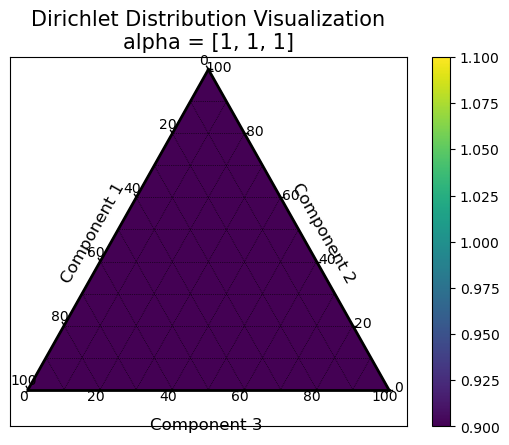

In [7]:
alpha = [1, 1, 1]
visualize_dirichlet_on_simplex(alpha)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ternary
from scipy.stats import dirichlet


def visualize_dirichlet_on_simplex(alpha, scale=200):
    """
    Visualize Dirichlet distribution on a 2-simplex (3-category) using ternary plot.

    Parameters:
    - alpha: List or array of 3 Dirichlet concentration parameters
    - scale: Granularity of the simplex grid
    """
    assert len(alpha) == 3, "This visualization only works for 3D Dirichlet."

    # Ternary plot setup
    fig, tax = ternary.figure(scale=scale)
    tax.boundary(linewidth=1.5)
    tax.gridlines(multiple=scale // 10, color="gray")
    tax.clear_matplotlib_ticks()
    tax.set_title(f"Dirichlet Distribution\nα = {alpha}", fontsize=15)
    tax.left_axis_label("x", fontsize=12)
    tax.right_axis_label("y", fontsize=12)
    tax.bottom_axis_label("z", fontsize=12)

    # Create grid and compute PDF
    heatmap = {}
    for i in range(scale + 1):
        for j in range(scale + 1 - i):
            k = scale - i - j
            point = np.array([i, j, k]) / scale
            # Skip invalid points when alpha < 1
            if np.any(point == 0) and np.any(np.array(alpha) < 1):
                continue
            pdf_val = dirichlet.pdf(point, alpha)
            heatmap[(i, j)] = pdf_val

    # Normalize heatmap
    max_pdf = max(heatmap.values())
    heatmap = {k: v / max_pdf for k, v in heatmap.items()}

    # Draw heatmap
    tax.heatmap(heatmap, style="triangular", cmap="plasma", colorbar=True)
    plt.tight_layout()
    plt.show()


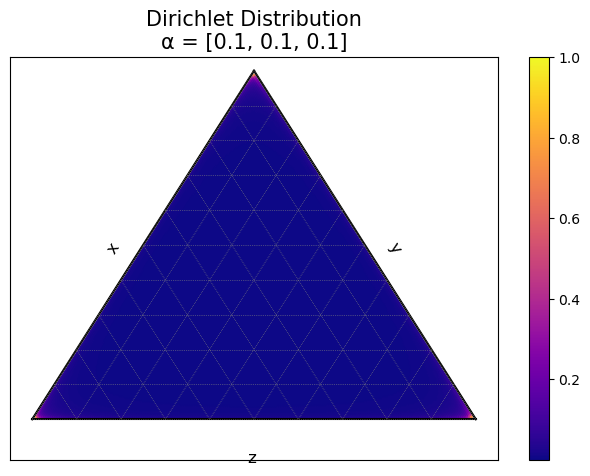

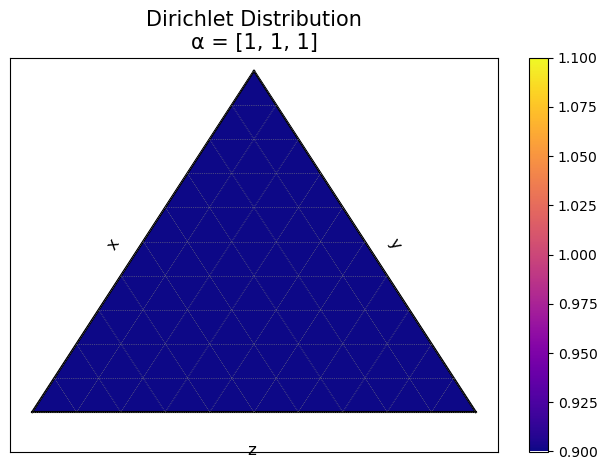

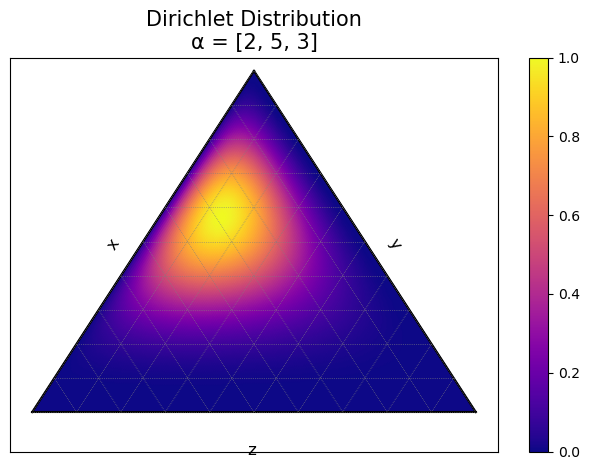

In [9]:
visualize_dirichlet_on_simplex([0.1, 0.1, 0.1])  # Sparse corners
visualize_dirichlet_on_simplex([1, 1, 1])        # Uniform
visualize_dirichlet_on_simplex([2, 5, 3])        # Skewed


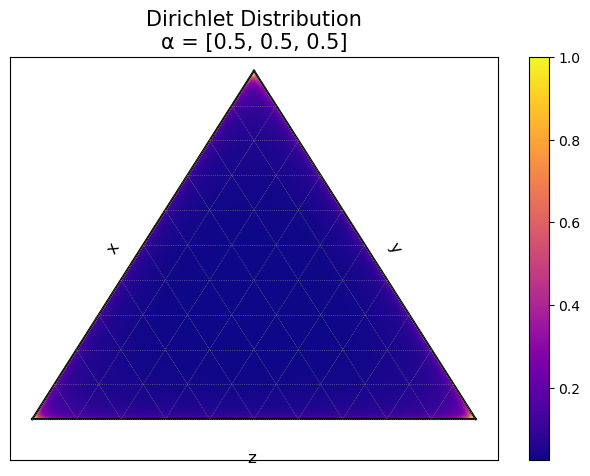

In [10]:
visualize_dirichlet_on_simplex([0.5, 0.5, 0.5])  # Sparse corners

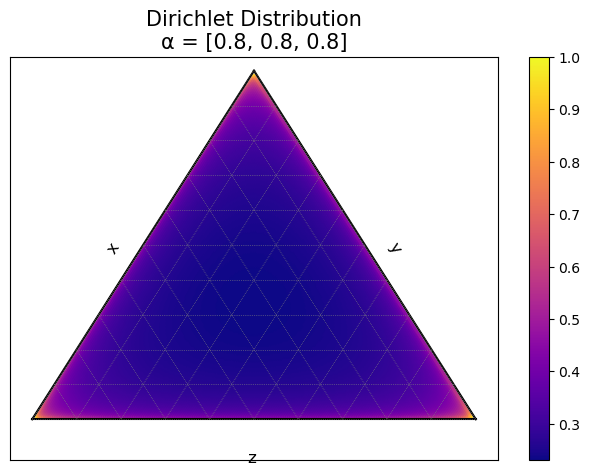

In [11]:
visualize_dirichlet_on_simplex([0.8, 0.8, 0.8])  # Sparse corners

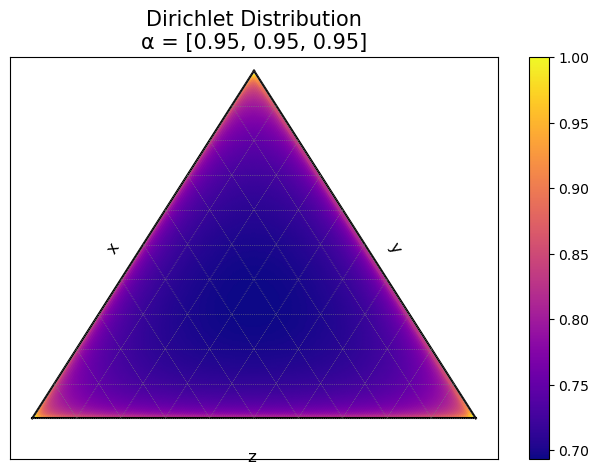

In [12]:
visualize_dirichlet_on_simplex([0.95, 0.95, 0.95])  # Sparse corners